In [1]:
# 第4章｜實做 CNN 買賣大盤：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.
已登入（使用快取憑證）。


In [2]:
QUICK_RUN = False  # True：只訓練少量 epoch，只用來快速檢查程式能不能跑

# 實做 CNN 買賣大盤

**對應影片**：第 4 章 單元 9「實做 CNN 買賣大盤」（觀念請看單元 8「CNN」）

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| 大盤 15 分 K，每 200 根 K 棒一段，用 for 迴圈切 | 加權指數日 K，每 `WINDOW` 天一段，用 `sliding_window_view` 一次切好 |
| `keras.optimizers.Adam(lr=..., decay=...)` | Keras 3 的參數改名為 `learning_rate`，`decay` 已移除 |
| 預測未來 10 根 K 棒的漲幅，報酬用指數點數相加 | 預測「買進 0050、持有 10 天」的報酬，用 `sim()` 回測 |

CNN 不用技術指標，直接「看」最近一段時間的走勢圖形。每段走勢先縮放到 0～1，模型只看形狀、不看指數高低。

In [3]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import finlab.ml.label as label
from finlab.backtest import sim
from keras import layers
from numpy.lib.stride_tricks import sliding_window_view

TRADE_STOCK = '0050'
ETF_TAX_RATIO = 0.001
HORIZON = 10
TRAIN_END = '2015-12-31'
TEST_START = '2016-01-01'
RANDOM_STATE = 0

## 1. 切出走勢片段

In [4]:
WINDOW = 60


def forward_return(dates: pd.DatetimeIndex, period: int) -> pd.Series:
    index = pd.MultiIndex.from_product([dates, [TRADE_STOCK]], names=['datetime', 'instrument'])
    return label.return_percentage(index, period=period).droplevel('instrument')


close = data.get('taiex_total_index:收盤指數')['TAIEX'].dropna()

windows = sliding_window_view(close.to_numpy(), WINDOW)
window_min = windows.min(axis=1, keepdims=True)
window_max = windows.max(axis=1, keepdims=True)
shapes = (windows - window_min) / (window_max - window_min)

sample_dates = close.index[WINDOW - 1:]
target = forward_return(sample_dates, HORIZON)
valid = target.notna().to_numpy()

X = shapes[valid][..., np.newaxis]
y = target[valid].to_numpy()
sample_dates = sample_dates[valid]
print('X 的形狀（樣本數, 天數, 1）：', X.shape)

X 的形狀（樣本數, 天數, 1）： (2888, 60, 1)


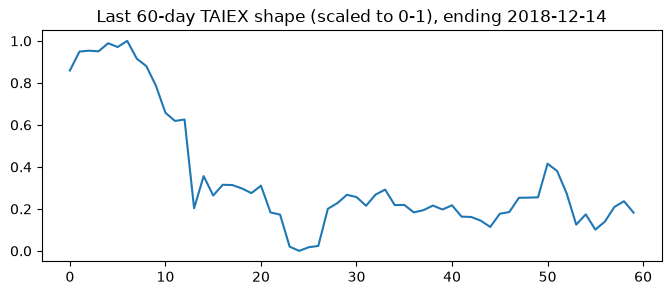

In [5]:
plt.figure(figsize=(8, 3))
plt.plot(X[-1, :, 0])
plt.title(f'Last {WINDOW}-day TAIEX shape (scaled to 0-1), ending {sample_dates[-1]:%Y-%m-%d}');

In [6]:
is_train = sample_dates <= TRAIN_END
is_test = sample_dates >= TEST_START
X_train, y_train, X_test, y_test = X[is_train], y[is_train], X[is_test], y[is_test]
print(f'訓練 {len(X_train)} 筆、測試 {len(X_test)} 筆')

訓練 2162 筆、測試 726 筆


## 2. 建立 CNN

- `Conv1D`：用一個小視窗在走勢上滑動，找出局部的形狀特徵（例如 V 形反轉、突破）。
- `AveragePooling1D`：把相鄰的特徵平均，縮短序列、保留重點。
- 最後接全連接層輸出預測的報酬率（迴歸問題，loss 用均方誤差）。

In [7]:
FILTERS = 16
KERNEL_SIZE = 5
POOL_SIZE = 2
DENSE_UNITS = 32
DROPOUT = 0.3
LEARNING_RATE = 5e-4

keras.utils.set_random_seed(RANDOM_STATE)
model = keras.Sequential([
    keras.Input(shape=X.shape[1:]),
    layers.Conv1D(FILTERS, KERNEL_SIZE, activation='relu'),
    layers.AveragePooling1D(POOL_SIZE),
    layers.Conv1D(FILTERS, KERNEL_SIZE, activation='relu'),
    layers.AveragePooling1D(POOL_SIZE),
    layers.Flatten(),
    layers.Dense(DENSE_UNITS, activation='relu'),
    layers.Dropout(DROPOUT),
    layers.Dense(1),
])
model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE), loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 56, 16)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 28, 16)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 24, 16)         │         1,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 12, 16)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,601 (29.69 KB)

 Trainable params: 7,601 (29.69 KB)

 Non-trainable params: 0 (0.00 B)

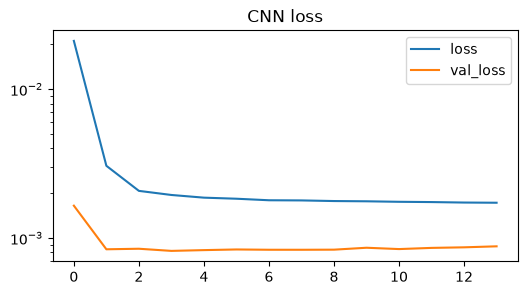

In [8]:
EPOCHS = 2 if QUICK_RUN else 100
BATCH_SIZE = 64
VALIDATION_FRACTION = 0.2
PATIENCE = 10

history = model.fit(
    X_train, y_train, validation_split=VALIDATION_FRACTION, epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)],
    verbose=0,
)
pd.DataFrame(history.history)[['loss', 'val_loss']].plot(figsize=(6, 3), logy=True, title='CNN loss');

## 3. 預測與回測

預測報酬和實際報酬的相關係數，可以看出模型有沒有抓到方向：

In [9]:
train_prediction = pd.Series(model.predict(X_train, verbose=0).ravel(), index=sample_dates[is_train])
test_prediction = pd.Series(model.predict(X_test, verbose=0).ravel(), index=sample_dates[is_test])
print(f'訓練期間相關係數：{np.corrcoef(train_prediction, y_train)[0, 1]:.3f}')
print(f'測試期間相關係數：{np.corrcoef(test_prediction, y_test)[0, 1]:.3f}')

訓練期間相關係數：0.062
測試期間相關係數：-0.030


預測報酬高於訓練期間第 `SIGNAL_QUANTILE` 百分位就買進，持有 `HORIZON` 天：

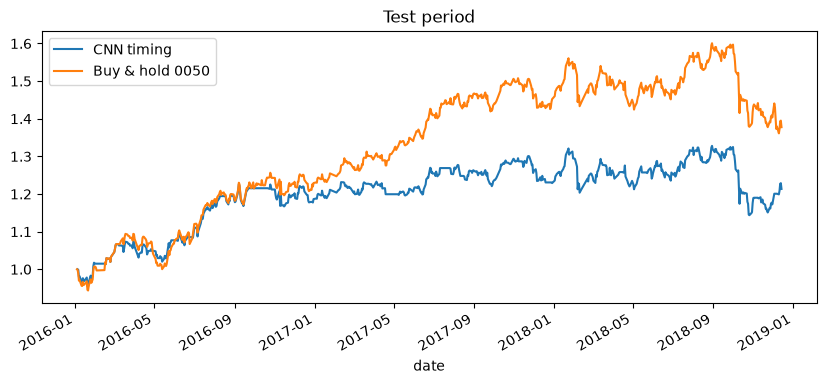

In [10]:
SIGNAL_QUANTILE = 0.7

threshold = train_prediction.quantile(SIGNAL_QUANTILE)
hold = (test_prediction > threshold).rolling(HORIZON, min_periods=1).max().astype(bool)
position = hold.to_frame(TRADE_STOCK)

strategy = sim(position, name='CNN timing', tax_ratio=ETF_TAX_RATIO)
buy_and_hold = sim(position.notna(), name='Buy & hold 0050', tax_ratio=ETF_TAX_RATIO)

pd.DataFrame({'CNN timing': strategy.creturn, 'Buy & hold 0050': buy_and_hold.creturn}).plot(
    figsize=(10, 4), title='Test period');

In [11]:
pd.DataFrame({
    name: {key: report.get_stats()[key] for key in ['cagr', 'max_drawdown', 'daily_sharpe']}
    for name, report in [('CNN timing', strategy), ('Buy & hold 0050', buy_and_hold)]
}).T.style.format({'cagr': '{:.2%}', 'max_drawdown': '{:.2%}', 'daily_sharpe': '{:.2f}'})

,cagr,max_drawdown,daily_sharpe
CNN timing,6.80%,-13.88%,0.43
Buy & hold 0050,11.50%,-14.96%,0.72


試試看：把 `WINDOW` 改成 20 或 120 天、或改變 `FILTERS`、`KERNEL_SIZE`，CNN 看到的「形狀」會不一樣。